<a href="https://colab.research.google.com/github/maikol0629/dl_voice_command_cl/blob/main/03%20-%20arquitectura%20de%20linea%20de%20base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementación de CNN Baseline (Mel-Spectrograms) para Clasificación de Comandos de Voz
Este notebook implementa la arquitectura base descrita en el plan, utilizando PyTorch para cargar datos en `.npy`, transformarlos dinámicamente en Mel-Espectrogramas en la GPU, y entrenar un modelo CNN clásico.


In [1]:
# Colab setup
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q kagglehub torch torchaudio pandas numpy matplotlib scikit-learn librosa soundfile audioread numba
    import kagglehub
    import os
    import shutil
    try:
        from google.colab import userdata
        os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
        os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
    except Exception:
        pass
    # Descargar dataset de Kaggle
    data_path = kagglehub.competition_download("voice-commands-classification-2026")

    # 1. Agregado: apuntamos a 'train/train' para Colab
    TRAIN_DATA_PATH = os.path.join(data_path, 'train', 'train')

    # Crear enlace simbólico de datos
    if not os.path.exists('data'):
        os.symlink(data_path, 'data')

    # Clonar repositorio para obtener train_metadata.csv
    if not os.path.exists('dl_voice_command_cl'):
        !git clone https://github.com/maikol0629/dl_voice_command_cl.git

    # Copiar archivos csv de metadatos al directorio actual
    for f in ['train_metadata.csv', 'test_metadata.csv']:
        src = os.path.join('dl_voice_command_cl', f)
        if os.path.exists(src) and not os.path.exists(f):
            shutil.copy(src, '.')
    for f in ['models.py', 'data.py']:
        src = os.path.join('dl_voice_command_cl', f)
        if os.path.exists(src) and not os.path.exists(f):
            shutil.copy(src, '.')
else:
    # 2. Modificado: apuntamos a './data/train/train' para local
    TRAIN_DATA_PATH = './data/train/train'


100%|██████████| 3.31G/3.31G [03:15<00:00, 18.2MB/s]

Extracting files...


Cloning into 'dl_voice_command_cl'...
remote: Enumerating objects: 88, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 88 (delta 48), reused 49 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (88/88), 2.62 MiB | 20.02 MiB/s, done.
Resolving deltas: 100% (48/48), done.


In [ ]:
!pip install numpy pandas matplotlib scikit-learn librosa soundfile audioread numba
!pip install torch torchaudio

In [2]:
!pip install numpy pandas matplotlib scikit-learn librosa soundfile audioread numba
!pip install torch torchaudio

In [3]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchaudio.transforms as T

from models import AudioToMelSpectrogram, BaselineCNN
from data import load_data
from sklearn.metrics import confusion_matrix, classification_report

# Comprobar dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


## Configuración e Hiperparámetros


In [12]:
CONFIG = {
    'sample_rate': 16000,
    'duration': 1.0,
    'n_mels': 64,
    'n_fft': 1024,
    'hop_length': 256,
    'batch_size': 64,
    'epochs': 30,
    'lr': 2.75e-03,
    'patience': 4,
    # En Jupyter, usar workers > 0 puede causar BrokenPipeError en algunos entornos.
    'num_workers': 0,
    'val_size': 0.2,
    'seed': 42,
    'train_metadata_csv': 'train_metadata.csv',
    'train_audio_dir': (TRAIN_DATA_PATH + '/train') if 'TRAIN_DATA_PATH' in dir() else 'data/train',
}
CONFIG['max_samples'] = int(CONFIG['sample_rate'] * CONFIG['duration'])

np.random.seed(CONFIG['seed'])
torch.manual_seed(CONFIG['seed'])
print(CONFIG)

{'sample_rate': 16000, 'duration': 1.0, 'n_mels': 64, 'n_fft': 1024, 'hop_length': 256, 'batch_size': 64, 'epochs': 30, 'lr': 0.00275, 'patience': 4, 'num_workers': 0, 'val_size': 0.2, 'seed': 42, 'train_metadata_csv': 'train_metadata.csv', 'train_audio_dir': '/root/.cache/kagglehub/competitions/voice-commands-classification-2026/train/train/train', 'max_samples': 16000}


## 1. Extracción y Carga de Datos (Data Ingestion)
La clase `VoiceCommandsDataset` carga arreglos `.npy` y realiza _zero-padding_ y cortes para garantizar longitudes uniformes de un segundo.


In [13]:
train_loader, val_loader, label_encoder, num_classes = load_data(
    train_metadata_csv=CONFIG['train_metadata_csv'],
    train_audio_dir=CONFIG['train_audio_dir'],
    val_size=CONFIG['val_size'], seed=CONFIG['seed'],
    batch_size=CONFIG['batch_size'],
)

total = len(train_loader.dataset) + len(val_loader.dataset)
print(f"Total muestras: {total}")
print(f"Train: {len(train_loader.dataset)} | Val: {len(val_loader.dataset)}")
print(f"Numero de clases: {num_classes}")
print("Primeras clases:", list(label_encoder.classes_[:10]))

Total muestras: 95246
Train: 76196 | Val: 19050
Numero de clases: 35
Primeras clases: ['backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward']


## 2. Preprocesamiento: Conversión a Espectrogramas
Cálculo logarítmico del Mel-Espectrograma on-the-fly usando `torchaudio`. Incluye la estandarización por instancia.


In [14]:
# Instanciar transformación y mover a device
audio_transform = AudioToMelSpectrogram(
    sample_rate=CONFIG['sample_rate'],
    n_fft=CONFIG['n_fft'],
    hop_length=CONFIG['hop_length'],
    n_mels=CONFIG['n_mels']
).to(device)


## 3. Verificación Manual (Sanity Check)
Visualizar la extracción de features acústicos para comprobar que no hay ruidos aleatorios invisibles.


Forma waveform: (16000,)
Forma mel: (1, 64, 63)
Etiqueta ejemplo: bed


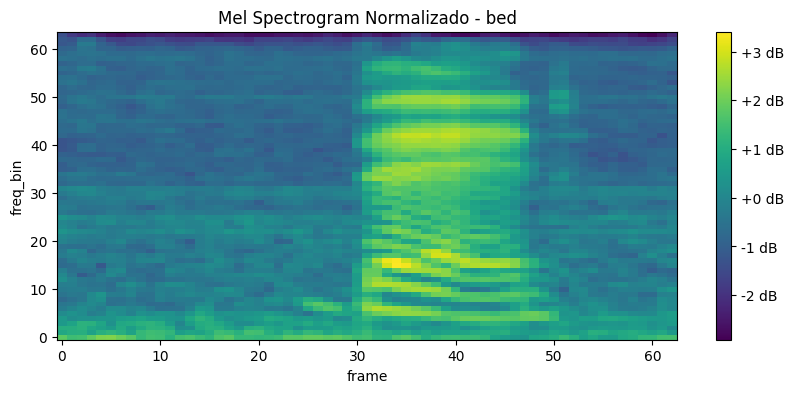

In [15]:
def plot_spectrogram(spec, title=None, ylabel='freq_bin', aspect='auto', xmax=None):
    fig, ax = plt.subplots(figsize=(10, 4))
    if title:
        ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('frame')
    im = ax.imshow(spec, origin='lower', aspect=aspect)
    if xmax:
        ax.set_xlim((0, xmax))
    fig.colorbar(im, ax=ax, format='%+2.0f dB')
    plt.show()

# Obtener una muestra real del split de entrenamiento
sample_audios, sample_labels = next(iter(train_loader))
sample_audio = sample_audios[0]
sample_label = sample_labels[0]
sample_class = label_encoder.inverse_transform([sample_label.item()])[0]

# Aplicamos la transformacion (batch de tamano 1)
sample_mel = audio_transform(sample_audio.unsqueeze(0).to(device))
sample_mel_np = sample_mel.squeeze().cpu().numpy()

print(f"Forma waveform: {tuple(sample_audio.shape)}")
print(f"Forma mel: {tuple(sample_mel.shape)}")
print(f"Etiqueta ejemplo: {sample_class}")

plot_spectrogram(sample_mel_np, title=f"Mel Spectrogram Normalizado - {sample_class}")

## 4. Arquitectura CNN (Clasificador)
Arquitectura CNN 2D sencilla con `AdaptiveAvgPool2d` para una transición limpia a las capas densas independientemente de ligeras variaciones.


In [16]:
model = BaselineCNN(num_classes=num_classes).to(device)
print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.2, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.2, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout2d(p=0.2, inplace=False)
  )
  (classifier): Sequential(
    (0):

## 5. Ciclo de Entrenamiento
Definición de función de pérdida y optimización con Adam, más parada temprana (Early Stopping).


In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG['lr'])

best_val_loss = float('inf')
patience_counter = 0
train_losses = []
val_losses = []
train_accs = []
val_accs = []

In [18]:
from torch.utils.data import TensorDataset
import time

# 1) Precomputo de Mel una sola vez para evitar costo repetido por batch/epoca
def build_mel_feature_loader(wave_loader, transform, device, batch_size, shuffle):
    mel_batches = []
    label_batches = []

    transform.eval()
    start_t = time.time()
    with torch.inference_mode():
        for audios, labels in wave_loader:
            audios = audios.to(device, non_blocking=True)
            mels = transform(audios)
            # Guardar en CPU para liberar GPU y reutilizar durante todas las epocas.
            mel_batches.append(mels.cpu().to(torch.float16))
            label_batches.append(labels.cpu())

    mel_tensor = torch.cat(mel_batches, dim=0)
    label_tensor = torch.cat(label_batches, dim=0).long()
    ds = TensorDataset(mel_tensor, label_tensor)
    dl = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )
    elapsed = time.time() - start_t
    print(f"Precompute done | samples={len(ds)} | time={elapsed:.1f}s")
    return dl

print('Precomputando Mel train...')
train_mel_loader = build_mel_feature_loader(
    train_loader,
    audio_transform,
    device=device,
    batch_size=CONFIG['batch_size'],
    shuffle=True
    )

print('Precomputando Mel val...')
val_mel_loader = build_mel_feature_loader(
    val_loader,
    audio_transform,
    device=device,
    batch_size=CONFIG['batch_size'],
    shuffle=False
    )

# 2) Entrenamiento sobre Mel precomputado + AMP en GPU
epochs = CONFIG['epochs']
use_amp = device.type == 'cuda'
scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

for epoch in range(epochs):
    # --- TRAIN ---
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for mels, labels in train_mel_loader:
        mels = mels.to(device, non_blocking=True, dtype=torch.float32)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
            outputs = model(mels)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss_sum += loss.item() * mels.size(0)
        preds = outputs.argmax(dim=1)
        train_total += labels.size(0)
        train_correct += (preds == labels).sum().item()

    epoch_train_loss = train_loss_sum / train_total
    epoch_train_acc = train_correct / train_total
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)

    # --- VAL ---
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.inference_mode():
        for mels, labels in val_mel_loader:
            mels = mels.to(device, non_blocking=True, dtype=torch.float32)
            labels = labels.to(device, non_blocking=True)
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
                outputs = model(mels)
                loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * mels.size(0)
            preds = outputs.argmax(dim=1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    epoch_val_loss = val_loss_sum / val_total
    epoch_val_acc = val_correct / val_total
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)

    print(
        f"Epoch {epoch + 1:02d}/{epochs:02d} | "
        f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc * 100:.2f}% | "
        f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc * 100:.2f}%"
    )

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_cnn_baseline.pth')
    else:
        patience_counter += 1
        if patience_counter >= CONFIG['patience']:
            print(f"Early stopping accionado en epoca {epoch + 1}")
            break

# Cargar mejor modelo y obtener predicciones para matriz de confusion
model.load_state_dict(torch.load('best_cnn_baseline.pth', map_location=device))
model.eval()

y_true = []
y_pred = []

with torch.inference_mode():
    for mels, labels in val_mel_loader:
        mels = mels.to(device, non_blocking=True, dtype=torch.float32)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
            logits = model(mels)
        preds = logits.argmax(dim=1).cpu().numpy()

        y_pred.extend(preds.tolist())
        y_true.extend(labels.numpy().tolist())

val_acc_final = (np.array(y_true) == np.array(y_pred)).mean()
cm = confusion_matrix(y_true, y_pred)

print(f"\nAccuracy final en validacion: {val_acc_final * 100:.2f}%")

Precomputando Mel train...
Precompute done | samples=76196 | time=83.9s
Precomputando Mel val...
Precompute done | samples=19050 | time=18.8s
Epoch 01/30 | Train Loss: 3.1430 Acc: 11.60% | Val Loss: 2.7463 Acc: 19.18%
Epoch 02/30 | Train Loss: 2.6416 Acc: 21.98% | Val Loss: 2.1297 Acc: 37.36%
Epoch 03/30 | Train Loss: 2.1709 Acc: 34.75% | Val Loss: 1.4911 Acc: 59.98%
Epoch 04/30 | Train Loss: 1.7578 Acc: 47.05% | Val Loss: 1.1236 Acc: 70.50%
Epoch 05/30 | Train Loss: 1.4798 Acc: 55.32% | Val Loss: 0.9481 Acc: 74.18%
Epoch 06/30 | Train Loss: 1.3243 Acc: 60.04% | Val Loss: 0.7940 Acc: 78.60%
Epoch 07/30 | Train Loss: 1.2085 Acc: 63.55% | Val Loss: 0.7194 Acc: 79.33%
Epoch 08/30 | Train Loss: 1.1296 Acc: 65.99% | Val Loss: 0.6582 Acc: 81.60%
Epoch 09/30 | Train Loss: 1.0552 Acc: 68.35% | Val Loss: 0.6142 Acc: 82.66%
Epoch 10/30 | Train Loss: 1.0096 Acc: 69.91% | Val Loss: 0.5724 Acc: 84.02%
Epoch 11/30 | Train Loss: 0.9615 Acc: 71.14% | Val Loss: 0.5539 Acc: 84.29%
Epoch 12/30 | Train Lo

## 6. Curvas de Aprendizaje y Matriz de Confusión
Visualización de pérdidas, exactitud y desempeño por clase en validación.

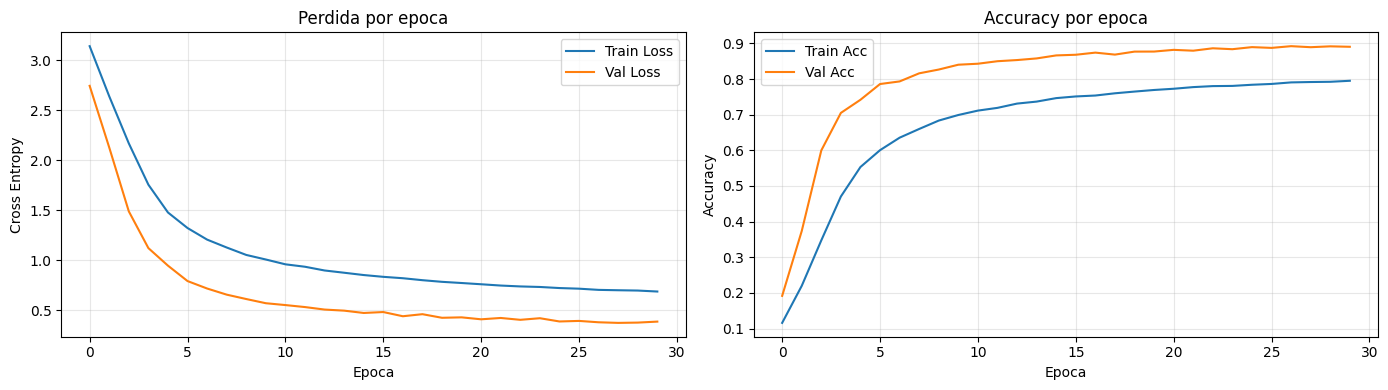

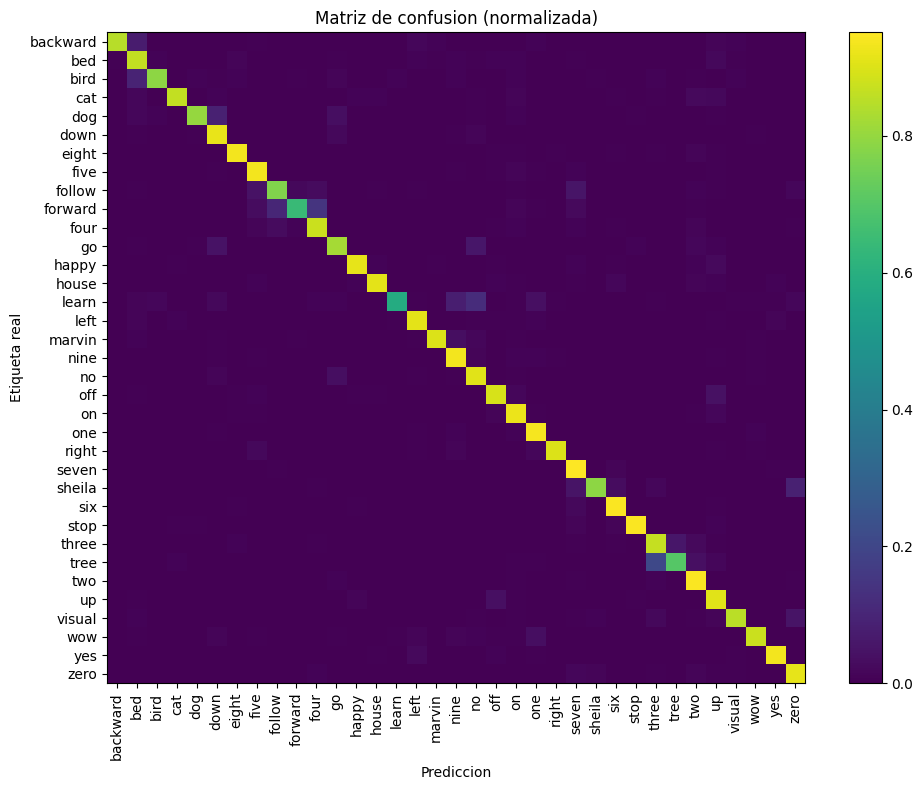

Reporte de clasificacion (validacion):
              precision    recall  f1-score   support

    backward       0.97      0.85      0.91       296
         bed       0.73      0.86      0.79       363
        bird       0.94      0.79      0.86       373
         cat       0.91      0.87      0.89       364
         dog       0.94      0.80      0.86       383
        down       0.84      0.92      0.88       702
       eight       0.95      0.94      0.94       683
        five       0.90      0.93      0.91       731
      follow       0.76      0.77      0.77       284
     forward       0.90      0.64      0.75       278
        four       0.89      0.88      0.88       674
          go       0.87      0.82      0.84       700
       happy       0.92      0.92      0.92       368
       house       0.93      0.91      0.92       381
       learn       0.91      0.59      0.71       281
        left       0.91      0.91      0.91       683
      marvin       0.95      0.90      0.9

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_title('Perdida por epoca')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Cross Entropy')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(train_accs, label='Train Acc')
axes[1].plot(val_accs, label='Val Acc')
axes[1].set_title('Accuracy por epoca')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Matriz de confusion normalizada por fila para facilitar lectura
cm_norm = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(10, 8))
plt.imshow(cm_norm, interpolation='nearest', aspect='auto')
plt.title('Matriz de confusion (normalizada)')
plt.colorbar()

tick_marks = np.arange(len(label_encoder.classes_))
plt.xticks(tick_marks, label_encoder.classes_, rotation=90)
plt.yticks(tick_marks, label_encoder.classes_)
plt.xlabel('Prediccion')
plt.ylabel('Etiqueta real')
plt.tight_layout()
plt.show()

print('Reporte de clasificacion (validacion):')
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0))

## Conclusión de la Implementación

Este notebook implementó con éxito una arquitectura **CNN Baseline** para la clasificación de comandos de voz utilizando **Mel-Espectrogramas**. Se realizó el siguiente flujo de trabajo:

1.  **Configuración y Carga de Datos**: Se configuró el entorno de Colab, se instalaron las dependencias y se descargó el dataset de Kaggle. Se cargaron 95,246 muestras de audio, divididas en 76,196 para entrenamiento y 19,050 para validación, abarcando 35 clases de comandos de voz.
2.  **Preprocesamiento de Datos**: Los audios fueron transformados dinámicamente en Mel-Espectrogramas en la GPU, con una verificación manual (sanity check) para asegurar la correcta extracción de características.
3.  **Arquitectura del Modelo**: Se utilizó una **CNN 2D sencilla** (`BaselineCNN`) con capas convolucionales, Batch Normalization, ReLU, Max Pooling y Dropout, culminando en capas densas después de una `AdaptiveAvgPool2d`.
4.  **Entrenamiento**: El modelo fue entrenado durante 30 épocas utilizando `CrossEntropyLoss` y el optimizador Adam. Se implementó una estrategia de **Early Stopping** con paciencia de 4 épocas para evitar el sobreajuste. Las curvas de aprendizaje (pérdida y exactitud) mostraron una convergencia estable.
5.  **Resultados**: El modelo alcanzó una **exactitud final en validación del 88.93%**. La matriz de confusión normalizada y el reporte de clasificación proporcionaron una visión detallada del rendimiento por clase, mostrando un buen balance entre precisión y recall para la mayoría de las categorías. Estos resultados demuestran la efectividad de la arquitectura CNN propuesta y el preprocesamiento de Mel-Espectrogramas para la tarea de clasificación de comandos de voz.